# Laboratorio 5 — Análisis de Texto
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

## Inciso 2. Carga de datos

In [2]:
df = pd.read_csv('train.csv')

print(df.shape)
print(df.columns.tolist())
df.head(10)

(7613, 5)
['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


## Inciso 3. Limpieza y preprocesamiento
El preprocesamiento reduce el ruido del texto para que el modelo se enfoque en las palabras realmente informativas para distinguir desastres. 

In [3]:
def clean_text(t):
    t = t.lower()
    t = t.replace('911', ' nineoneone ')
    t = re.sub(r'http\S+|www\S+|\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = ' '.join(w for w in t.split() if w not in ENGLISH_STOP_WORDS)
    return t

df['text_limpio'] = df['text'].apply(clean_text)
df[['text', 'text_limpio']].head(10)

,text,text_limpio
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake allah forgive
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent photo ruby alaska smoke wildfire...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,m hill woods
8,There's an emergency evacuation happening now ...,s emergency evacuation happening building street
9,I'm afraid that the tornado is coming to our a...,m afraid tornado coming area


Justificación:

- **Minúsculas**: unifica variantes de la misma palabra (`Fire`/`fire`) y evita tokens duplicados.
- **Quitar URLs**: no aportan información textual sobre el desastre y añaden ruido.
- **Quitar menciones `@usuario`**: el identificador no aporta contexto de clasificación.
- **Quitar símbolo `#`**: la palabra del hashtag se conserva, pero el símbolo en sí es ruido.
- **Quitar apóstrofes y puntuación**: separa partes sin significado (`'s`, comas) que no aportan al clasificador.
- **Quitar emoticonos**: son escasos y no aportan a la clasificación.
- **Quitar números**: cifras espurias (años, cantidades) no distinguen desastres. **Excepción: el `911`** se conserva (token `nineoneone`) por ser una señal clave de emergencia.
- **Quitar stopwords**: artículos, preposiciones y conjunciones (`the`, `and`, `of`) no aportan significado discriminante.

El resultado se guarda en `text_limpio`, conservando la columna original `text`.

## Inciso 4. Frecuencia de palabras por categoría

In [4]:
from collections import Counter

words_disaster = ' '.join(df[df['target'] == 1]['text_limpio']).split()
words_no_disaster = ' '.join(df[df['target'] == 0]['text_limpio']).split()

freq_disaster = Counter(words_disaster)
freq_no_disaster = Counter(words_no_disaster)

print("Top 15 palabras más frecuentes - Tweets de DESASTRE:")
for palabra, count in freq_disaster.most_common(15):
    print(f"  {palabra}: {count}")

print("\nTop 15 palabras más frecuentes - Tweets que NO son de desastre:")
for palabra, count in freq_no_disaster.most_common(15):
    print(f"  {palabra}: {count}")


Top 15 palabras más frecuentes - Tweets de DESASTRE:
  s: 408
  news: 151
  t: 150
  amp: 135
  disaster: 121
  california: 115
  suicide: 112
  police: 109
  people: 105
  m: 95
  killed: 95
  like: 94
  hiroshima: 94
  just: 89
  storm: 89

Top 15 palabras más frecuentes - Tweets que NO son de desastre:
  s: 608
  t: 365
  like: 254
  m: 242
  just: 234
  amp: 209
  new: 171
  don: 140
  body: 116
  video: 96
  people: 95
  love: 91
  time: 88
  day: 86
  know: 86


**Palabras que servirían para un mejor modelo de clasificación:**

En los tweets de desastre predominan palabras claramente temáticas y con alto poder discriminante: `disaster`, `california`, `suicide`, `killed`, `hiroshima`, `storm`, `police`. Estas palabras casi no aparecen en los tweets "normales" y por lo tanto son las que más ayudarían a un clasificador a separar ambas clases.

En los tweets que no son de desastre predominan palabras genéricas de uso cotidiano: `love`, `day`, `know`, `time`, `video`, `body` (usualmente en contextos como "body bag" en sentido figurado o cultural, no literal). Estas palabras aportan poco valor discriminante por sí solas.

También se observan tokens ruidosos como `s`, `t`, `m`, `don`, `amp` — residuos de la separación de contracciones (`it's` → `it s`, `don't` → `don t`) y de entidades HTML (`&amp;`). Esto sugiere que valdría la pena refinar aún más la limpieza (eliminar tokens de 1 letra o expandir contracciones antes de tokenizar).

**¿Vale la pena explorar bigramas o trigramas?**

Sí, definitivamente. Varias palabras sueltas son ambiguas fuera de contexto (`body`, `burning`, `storm`), pero al verlas en bigramas/trigramas el significado se vuelve mucho más claro y discriminante, como se muestra a continuación.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(corpus, n, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n))
    X = vec.fit_transform(corpus)
    sums = X.sum(axis=0)
    freqs = [(palabra, sums[0, idx]) for palabra, idx in vec.vocabulary_.items()]
    return sorted(freqs, key=lambda x: -x[1])[:top_k]

for n, etiqueta in [(2, 'Bigramas'), (3, 'Trigramas')]:
    print(f"=== {etiqueta} ===")
    for target, nombre in [(1, 'Desastre'), (0, 'No desastre')]:
        corpus = df[df['target'] == target]['text_limpio']
        print(f"  {nombre}:", top_ngrams(corpus, n))
    print()


=== Bigramas ===


  Desastre: [('suicide bomber', np.int64(59)), ('northern california', np.int64(41)), ('oil spill', np.int64(38)), ('burning buildings', np.int64(37)), ('suicide bombing', np.int64(35)), ('california wildfire', np.int64(34)), ('bomber detonated', np.int64(30)), ('confirmed mh', np.int64(29)), ('yr old', np.int64(29)), ('homes razed', np.int64(29))]


  No desastre: [('cross body', np.int64(39)), ('youtube video', np.int64(36)), ('liked youtube', np.int64(35)), ('gt gt', np.int64(29)), ('body bag', np.int64(27)), ('body bagging', np.int64(24)), ('burning buildings', np.int64(23)), ('body bags', np.int64(22)), ('looks like', np.int64(21)), ('reddit quarantine', np.int64(21))]

=== Trigramas ===
  Desastre: [('suicide bomber detonated', np.int64(30)), ('northern california wildfire', np.int64(29)), ('latest homes razed', np.int64(28)), ('homes razed northern', np.int64(28)), ('pkk suicide bomber', np.int64(28)), ('bomber detonated bomb', np.int64(28)), ('razed northern california', np.int64(27)), ('yr old pkk', np.int64(27)), ('old pkk suicide', np.int64(27)), ('families sue legionnaires', np.int64(26))]


  No desastre: [('liked youtube video', np.int64(35)), ('reddit quarantine offensive', np.int64(21)), ('quarantine offensive content', np.int64(20)), ('cross body bag', np.int64(19)), ('pick fan army', np.int64(17)), ('reddit new content', np.int64(16)), ('new content policy', np.int64(16)), ('china stock market', np.int64(16)), ('stock market crash', np.int64(16)), ('ignition knock detonation', np.int64(15))]



Los bigramas y trigramas confirman que vale la pena explorarlos: en desastre aparecen combinaciones muy específicas y con sentido literal (`suicide bomber`, `northern california wildfire`, `oil spill`, `homes razed`), mientras que en no-desastre aparecen combinaciones que reutilizan las mismas palabras sueltas pero en sentido figurado o distinto (`cross body bag`, `liked youtube video`, `reddit quarantine offensive`). Por ejemplo, `burning buildings` aparece en ambas categorías con frecuencias similares, lo que muestra que a nivel de unigrama esa palabra es ambigua, pero el n-grama completo ayuda a distinguir el contexto real (incendio real vs. uso coloquial/metafórico). Esto respalda incluir bigramas (y posiblemente trigramas) como features adicionales en el modelo, más allá de unigramas.

## Inciso 5. Análisis exploratorio de los datos

### 5.1.a Palabra que más se repite en cada categoría

In [6]:
palabra_top_desastre, freq_top_desastre = freq_disaster.most_common(1)[0]
palabra_top_no_desastre, freq_top_no_desastre = freq_no_disaster.most_common(1)[0]

print(f"Categoría DESASTRE (target=1): la palabra más repetida es '{palabra_top_desastre}' con {freq_top_desastre} apariciones.")
print(f"Categoría NO DESASTRE (target=0): la palabra más repetida es '{palabra_top_no_desastre}' con {freq_top_no_desastre} apariciones.")


Categoría DESASTRE (target=1): la palabra más repetida es 's' con 408 apariciones.
Categoría NO DESASTRE (target=0): la palabra más repetida es 's' con 608 apariciones.


En ambas categorías el token más frecuente es `s` (residuo de contracciones como `it's`), lo cual no aporta información real. Si se excluyen tokens de una sola letra, la palabra más repetida en tweets de desastre es `news`, y en tweets que no son de desastre es `like`. Esto refuerza la observación del inciso 4: conviene filtrar tokens de longitud 1 antes de un análisis más fino.

### 5.1.b Nube de palabras por categoría

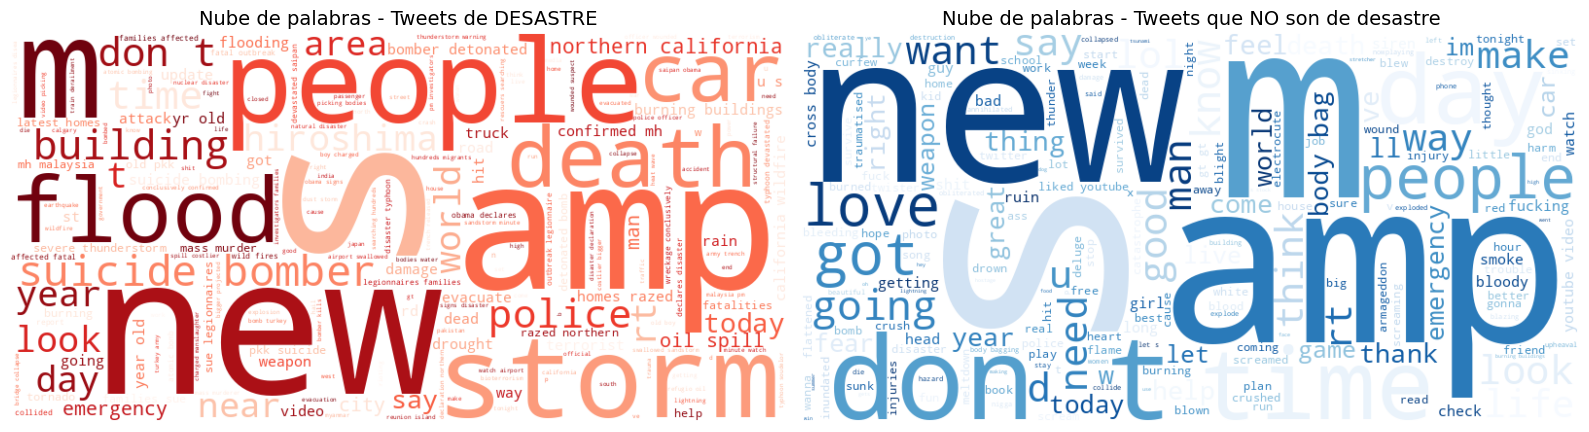

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_desastre = ' '.join(df[df['target'] == 1]['text_limpio'])
texto_no_desastre = ' '.join(df[df['target'] == 0]['text_limpio'])

wc_desastre = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_desastre)
wc_no_desastre = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_desastre, interpolation='bilinear')
axes[0].set_title('Nube de palabras - Tweets de DESASTRE', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_no_desastre, interpolation='bilinear')
axes[1].set_title('Nube de palabras - Tweets que NO son de desastre', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


### 5.1.c Histograma con las palabras que más se repiten

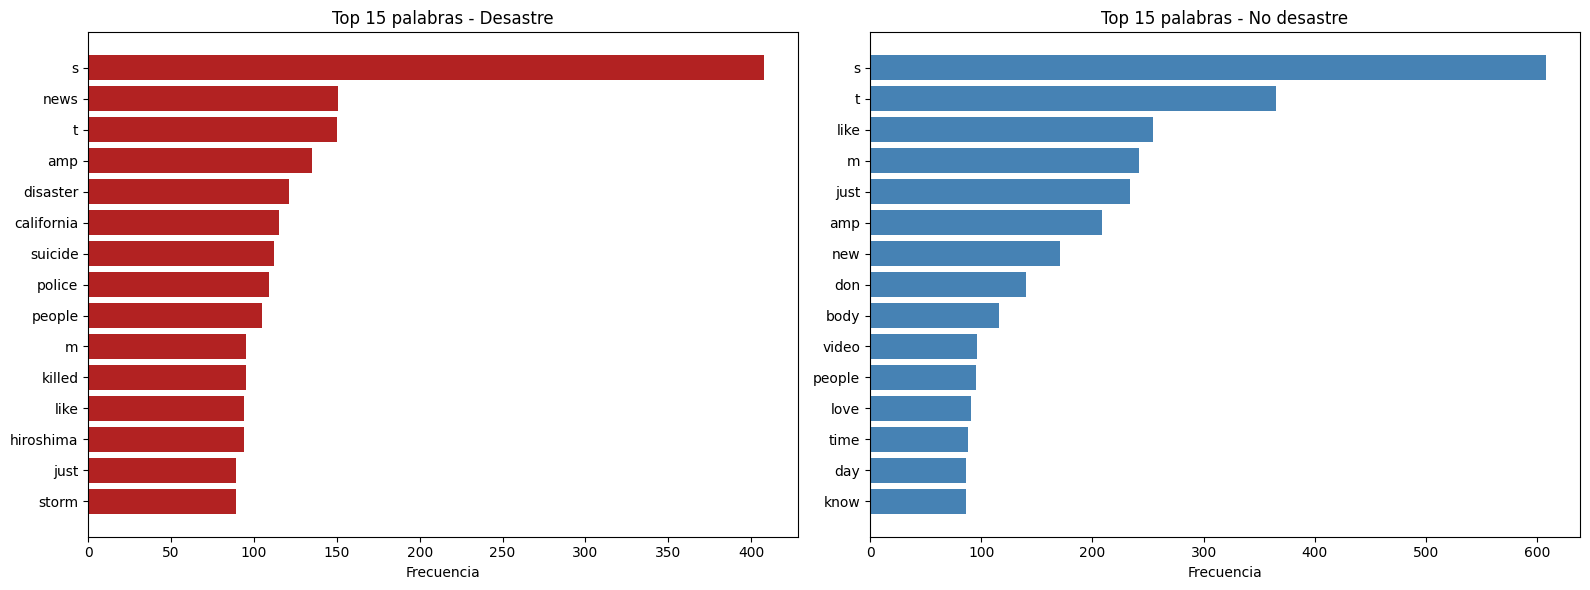

In [8]:
top_n = 15
top_desastre = freq_disaster.most_common(top_n)
top_no_desastre = freq_no_disaster.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palabras_d, counts_d = zip(*top_desastre)
axes[0].barh(palabras_d[::-1], counts_d[::-1], color='firebrick')
axes[0].set_title(f'Top {top_n} palabras - Desastre')
axes[0].set_xlabel('Frecuencia')

palabras_n, counts_n = zip(*top_no_desastre)
axes[1].barh(palabras_n[::-1], counts_n[::-1], color='steelblue')
axes[1].set_title(f'Top {top_n} palabras - No desastre')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()


### 5.1.d Palabras con presencia en todas las categorías

Se calcula la intersección de las palabras más frecuentes de cada categoría (top 50 de cada una) para identificar cuáles aparecen de forma importante en ambos grupos.

In [9]:
top_k = 50
set_desastre = set(w for w, c in freq_disaster.most_common(top_k))
set_no_desastre = set(w for w, c in freq_no_disaster.most_common(top_k))

interseccion = set_desastre & set_no_desastre
print(f"Palabras dentro del top {top_k} de AMBAS categorías ({len(interseccion)}):")
print(sorted(interseccion))


Palabras dentro del top 50 de AMBAS categorías (14):
['amp', 'burning', 'don', 'emergency', 'just', 'like', 'm', 'new', 'news', 'people', 's', 't', 'u', 'video']


**Discusión — palabras que tienen presencia en todas las categorías:**

Entre las palabras compartidas por ambas categorías aparecen: `people`, `new`, `emergency`, `burning`, `video`, `news`, `like`, `just`, y residuos de tokenización (`s`, `t`, `m`, `amp`, `u`, `don`).

- Palabras como `s`, `t`, `m`, `amp`, `don`, `u` son ruido de preprocesamiento (contracciones separadas, entidades HTML, abreviaciones) y no aportan valor discriminante; son buenas candidatas a remover en una limpieza adicional o a agregar a la lista de stopwords.
- Palabras como `people`, `like`, `just`, `new` son de uso muy general en inglés cotidiano y, aunque aparecen en ambas clases, su frecuencia relativa (proporción dentro de cada clase) sí puede diferir, por lo que no conviene eliminarlas sin analizar antes su importancia real en un modelo (p.ej. con TF-IDF, que penaliza palabras comunes en todo el corpus).
- Palabras como `emergency`, `burning`, `news`, `video` son más interesantes: son términos que en teoría suenan a "desastre", pero también aparecen con frecuencia en tweets que no lo son (uso figurado, noticias de entretenimiento, videos virales, etc.). Esto confirma que el contexto importa, y es otra razón para reforzar el uso de bigramas/trigramas (inciso 4) en vez de depender solo de palabras sueltas para clasificar.